In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

- Loading the dataset

In [2]:
df1 = pd.read_csv('heart.csv')

In [3]:
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


- Now we will make a copy of that dataset

In [4]:
df = df1.copy()

#Initial Data Cleaning

- Initial inspections

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
563,44,1,0,112,290,0,0,153,0,0.0,2,1,2,0
702,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
463,43,1,0,110,211,0,1,161,0,0.0,2,0,3,1
715,70,1,1,156,245,0,0,143,0,0.0,2,0,2,1
443,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.duplicated().sum()

np.int64(723)

There is 723 duplicated columns. We will remove duplicated columns otherwise it will cause data leakage.

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(302, 14)

In [11]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
280,45,0,1,130,234,0,0,175,0,0.6,1,0,2,1
652,66,0,3,150,226,0,1,114,0,2.6,0,0,2,1
533,53,0,0,138,234,0,0,160,0,0.0,2,0,2,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
580,46,1,1,101,197,1,1,156,0,0.0,2,0,3,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


- describe function on numerical columns

In [13]:
df[['age','trestbps','chol','thalach','oldpeak']].describe()

,age,trestbps,chol,thalach,oldpeak
count,302.00000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046
std,9.04797,17.563394,51.753489,22.903527,1.161452
min,29.00000,94.000000,126.000000,71.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000
75%,61.00000,140.000000,274.750000,166.000000,1.600000
max,77.00000,200.000000,564.000000,202.000000,6.200000


##Insights:

#### 1. Age
- **Range:** 29–77 years  
- **Mean:** ~54 years  
- **Percentiles:** 25th = 48, 75th = 61  
- **Insight:** Skews older (50s–60s). Heart disease risk rises with age, so this distribution is expected.

---

#### 2. Resting Blood Pressure (`trestbps`)
- **Range:** 94–200 mmHg  
- **Mean:** ~132 mmHg  
- **Categories:**  
  - Normal: <120  
  - Elevated: 120–129  
  - Stage 1 Hypertension: 130–139  
- **Insight:** Mean (131.6) falls in Stage 1 Hypertension.  
  - 75% ≥120 → majority already elevated/hypertensive.  
  - Max = 200 → Hypertensive Crisis concern.

---

#### 3. Cholesterol (`chol`)
- **Range:** 126–564 mg/dL  
- **Mean:** 246 mg/dL  
- **Categories:**  
  - Desirable: <200  
  - Borderline: 200–239  
  - High: ≥240  
- **Insight:** Mean in **High** range.  
  - 75% ≥211 → widespread cholesterol issues.  
  - Max = 564 → possible outlier (check data entry).  
- **Std Dev:** 51.6 → wide variation.

---

#### 4. Maximum Heart Rate (`thalach`)
- **Range:** 71–202 bpm  
- **Mean:** ~149 bpm  
- **Percentiles:** 25th = 132, 75th = 166  
- **Insight:** Mean suggests good stress-test performance.  
  - Lower max HR → higher cardiac risk.  
  - Distribution fairly symmetric around ~152.

---

#### 5. ST Depression (`oldpeak`)
- **Range:** 0–6.2  
- **Mean:** ~1.07  
- **Median:** 0.8  
- **Insight:**  
  - Higher values → ischemia (reduced blood flow).  
  - 25% = 0 → no ST depression in a quarter of patients.  
  - Mean > median → right-skewed with extreme highs.  
  - Max = 6.2 → severe ischemia cases.

---

###Key Concerns

1. Cholesterol max (564) is extreme, I will check for outliers/data errors
2. Oldpeak has 25% zeros, I have to investigate if these are truly healthy or missing values
3. Blood pressure max (200) is dangerously high, I have to examine if these patients are correctly classified


In [14]:
df[df['chol']==564]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1


- Yes, This is a VALID clinical case!

In [15]:
df[df['oldpeak']==0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
19,58,1,2,140,211,1,0,165,0,0.0,2,0,2,1
23,63,0,2,135,252,0,0,172,0,0.0,2,0,2,1
24,42,0,2,120,209,0,1,173,0,0.0,1,0,2,1
27,58,0,1,136,319,1,0,152,0,0.0,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1
708,60,0,2,120,178,1,1,96,0,0.0,2,0,2,1
720,64,1,2,140,335,0,1,158,0,0.0,2,0,2,0
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0


- These are truly healthy values (Not missing)

**reason:** The 25% of patients with oldpeak=0 represent valid clinical measurements, not missing data — this indicates no ST depression during exercise stress testing. However, many of these patients still have heart disease (target=1), proving that oldpeak alone is insufficient for diagnosis and other risk factors (cp, ca, thal, cholesterol) must be considered jointly.

In [16]:
df[df['trestbps']==200]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
175,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0


- Yes, this is valid — blood pressure of 200 mmHg indicates Stage 2 Hypertension (severe), which is clinically possible and often seen in high-risk cardiac patients.

#Exploratory Data Analysis


- Numerical columns: Age, trestbps, chol, thalach , oldpeak

- Categorical columns: sex, cp, fbs, restecg, exang, slope, ,ca, thal,target

- Mixed columns: there is no mixed columns

In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


##1. Univariate Analysis

###Age
**Conclusions:**
- This column is slightly left skewed



In [18]:
df['age'].describe()

,age
count,302.00000
mean,54.42053
std,9.04797
min,29.00000
25%,48.00000
50%,55.50000
75%,61.00000
max,77.00000


<Axes: ylabel='Frequency'>

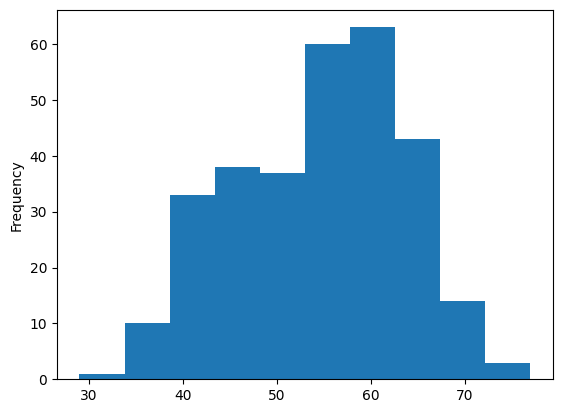

In [19]:
df['age'].plot(kind='hist')

<Axes: ylabel='Density'>

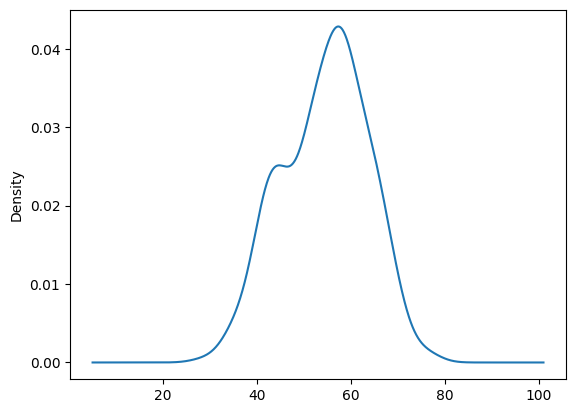

In [20]:
df['age'].plot(kind='kde')

In [21]:
df['age'].skew()

np.float64(-0.20374327959596905)

<Axes: >

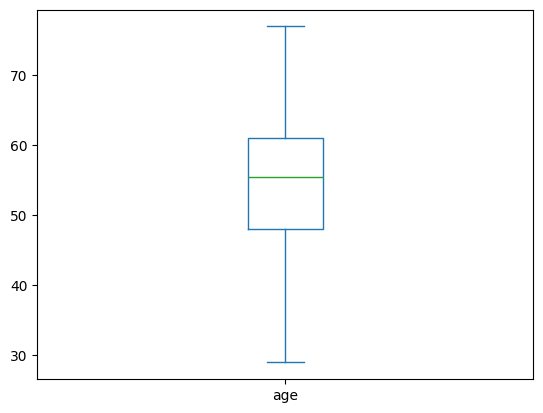

In [22]:
df['age'].plot(kind='box')

In [23]:
df['age']

,age
0,52
1,53
2,70
3,61
4,62
...,...
723,68
733,44
739,52
843,59


###trestbps (`Resting Blood Pressure`) column

**Conclusion:**
- This column is slightly right skewed
- There is some extreme values but those are valid

In [24]:
df['trestbps'].describe()

,trestbps
count,302.000000
mean,131.602649
std,17.563394
min,94.000000
25%,120.000000
50%,130.000000
75%,140.000000
max,200.000000


<Axes: ylabel='Frequency'>

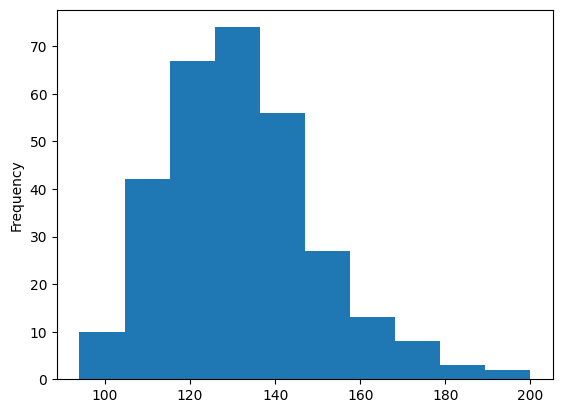

In [25]:
df['trestbps'].plot(kind='hist')

<Axes: ylabel='Density'>

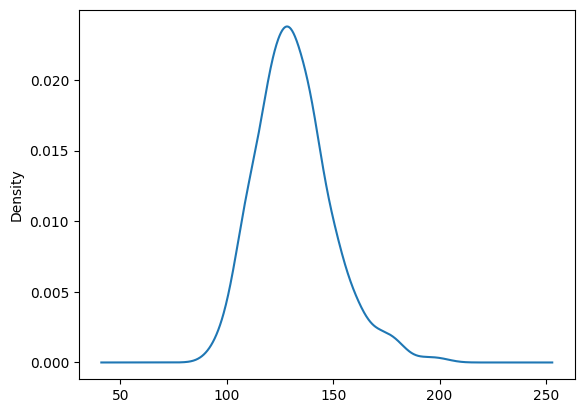

In [26]:
df['trestbps'].plot(kind='kde')

In [27]:
df['trestbps'].skew()

np.float64(0.7165414326647316)

<Axes: >

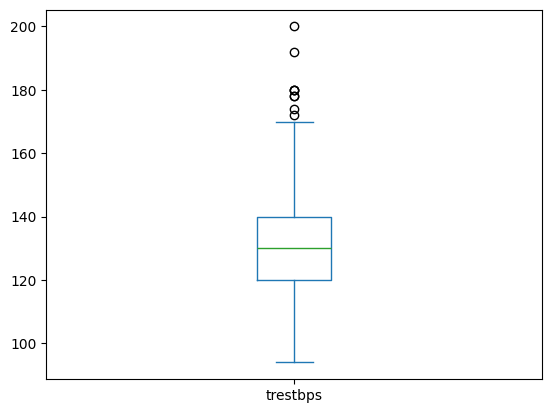

In [28]:
df['trestbps'].plot(kind='box')

In [29]:
df[df['trestbps']>170]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
29,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
47,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
87,59,0,0,174,249,0,1,143,1,0.0,1,0,2,0
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
151,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0
175,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
343,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
396,68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
528,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1


### chol (`Cholesterol`) column
- Cholesterol shows a right-skewed distribution with extreme values up to 564 mg/dL — all are clinically valid, supported by other risk factors (age, oldpeak, ca, thal)

In [30]:
df['chol'].describe()

,chol
count,302.000000
mean,246.500000
std,51.753489
min,126.000000
25%,211.000000
50%,240.500000
75%,274.750000
max,564.000000


<Axes: ylabel='Frequency'>

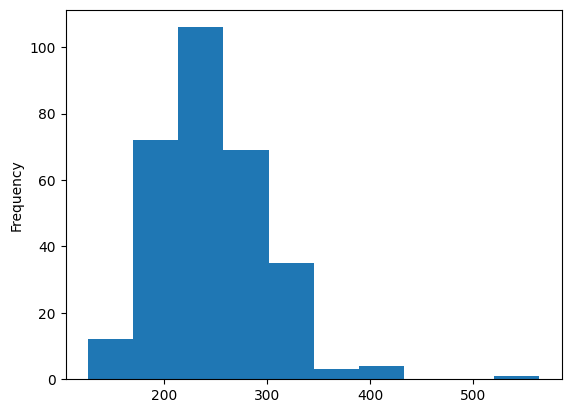

In [31]:
df['chol'].plot(kind='hist')

<Axes: ylabel='Density'>

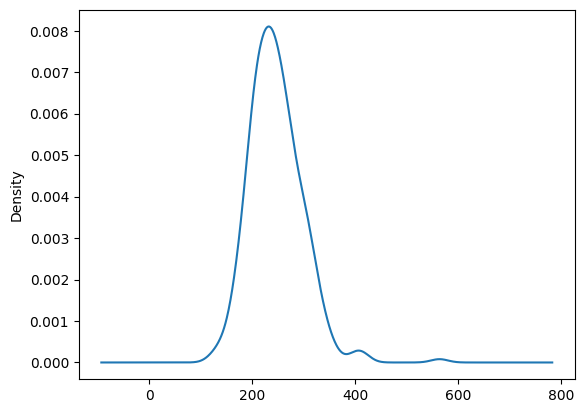

In [32]:
df['chol'].plot(kind='kde')

In [33]:
df['chol'].skew()

np.float64(1.147332413980798)

<Axes: >

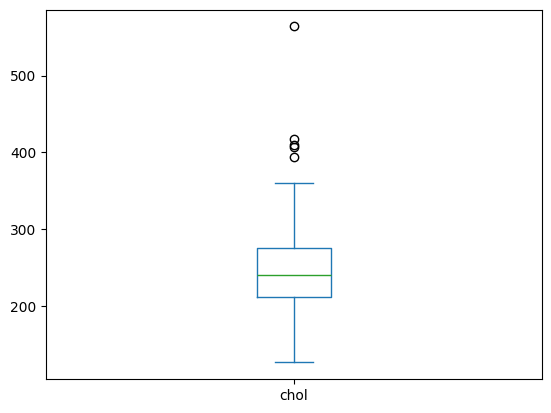

In [34]:
df['chol'].plot(kind='box')

In [35]:
df[df['chol']>380]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
123,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
179,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
255,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
450,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0


###thalach (`Maximum heart rate`)
- Thalach follows a roughly normal distribution (peak: 150-160 bpm), with the minimum value of 71 bpm from a 67-year-old patient — clinically valid due to age-related decline or medication effects.

In [36]:
df['thalach'].describe()

,thalach
count,302.000000
mean,149.569536
std,22.903527
min,71.000000
25%,133.250000
50%,152.500000
75%,166.000000
max,202.000000


<Axes: ylabel='Frequency'>

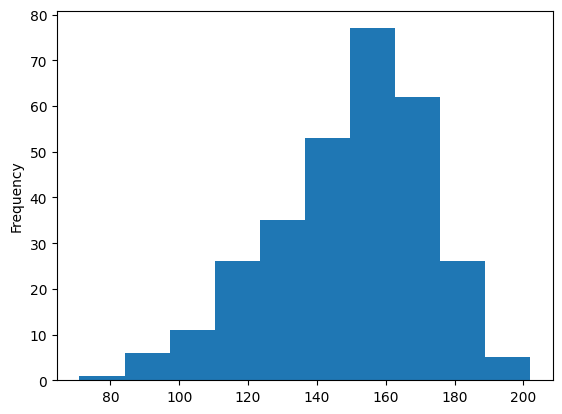

In [37]:
df['thalach'].plot(kind='hist')

<Axes: ylabel='Density'>

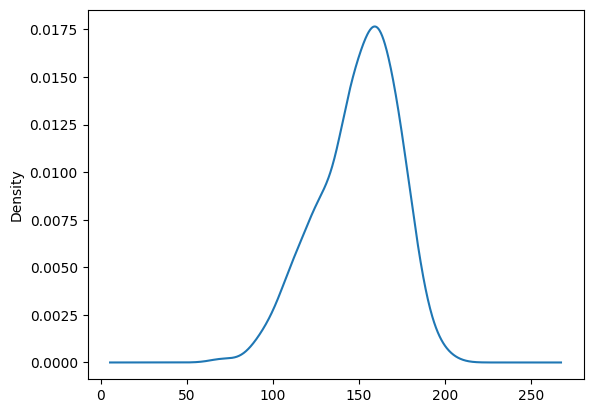

In [38]:
df['thalach'].plot(kind='kde')

In [39]:
df['thalach'].skew()

np.float64(-0.5326712468229613)

<Axes: >

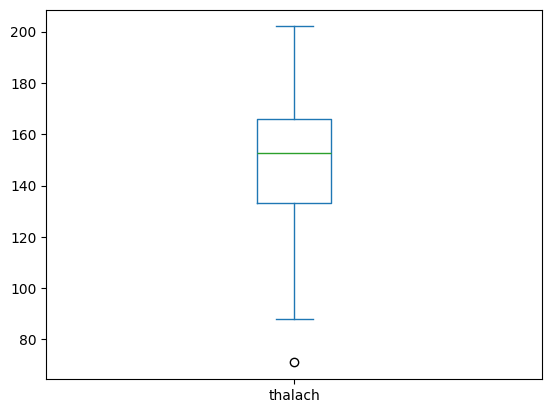

In [40]:
df['thalach'].plot(kind='box')

In [41]:
df[df['thalach']<80]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
267,67,1,0,120,237,0,1,71,0,1.0,1,0,2,0


### oldpeak (`Maximum heart rate`) column
- this column shows a right skewed distribution.
- All extreme oldpeak values (4.2-6.2 mm) are clinically valid

In [42]:
df['oldpeak'].describe()

,oldpeak
count,302.000000
mean,1.043046
std,1.161452
min,0.000000
25%,0.000000
50%,0.800000
75%,1.600000
max,6.200000


<Axes: ylabel='Frequency'>

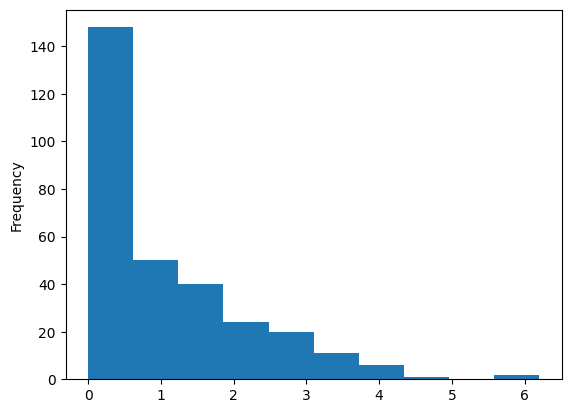

In [43]:
df['oldpeak'].plot(kind='hist')

<Axes: ylabel='Density'>

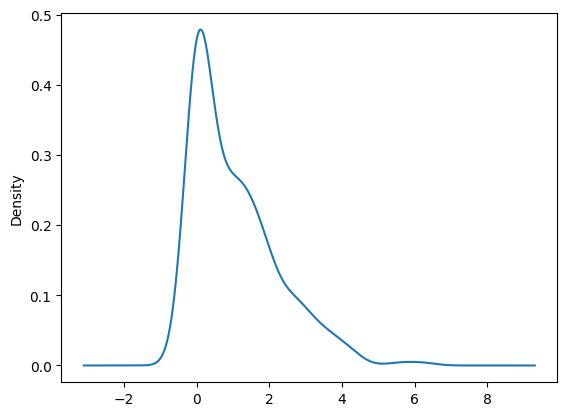

In [44]:
df['oldpeak'].plot(kind='kde')

In [45]:
df['oldpeak'].skew()

np.float64(1.266172720910219)

<Axes: >

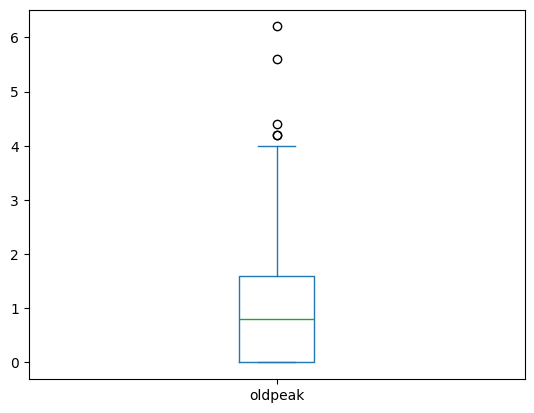

In [46]:
df['oldpeak'].plot(kind='box')

In [47]:
df[df['oldpeak']>4]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
13,51,1,0,140,298,0,1,122,1,4.2,1,3,3,0
54,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
69,62,0,0,160,164,0,0,145,0,6.2,0,3,3,0
528,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1


###Sex column
- Females show a surprisingly higher disease rate (75%) compared to males (44.7%) in this dataset, suggesting possible selection bias or more severe symptoms in tested women.

In [48]:
df['sex'].value_counts()

,count
sex,
1,206
0,96


<Axes: xlabel='sex'>

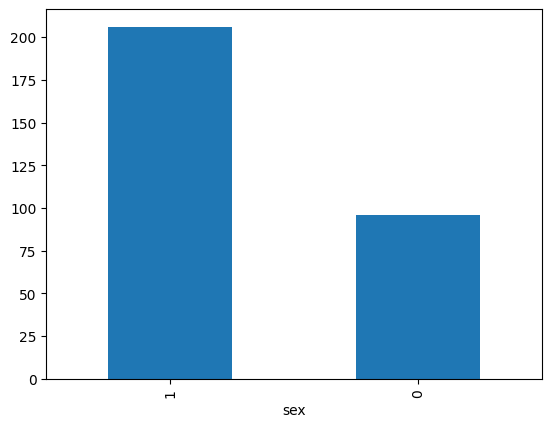

In [49]:
df['sex'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

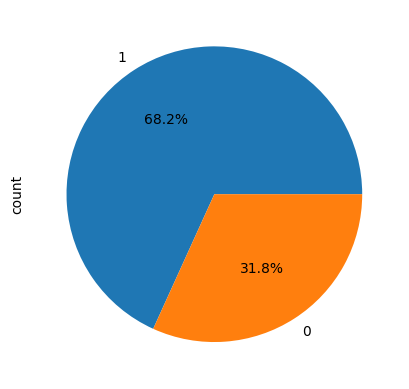

In [50]:
df['sex'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [51]:
df.groupby(['sex', 'target']).size().unstack()

target,0,1
sex,,
0,24,72
1,114,92


###cp (`chest pain`) column
- everything is fine in this column

In [52]:
df['cp'].value_counts()

,count
cp,
0,143
2,86
1,50
3,23


<Axes: ylabel='count'>

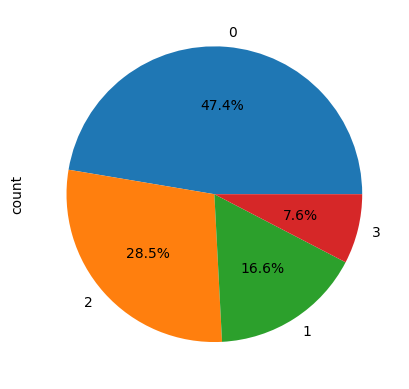

In [53]:
df['cp'].value_counts().plot(kind = 'pie',autopct='%1.1f%%')

###fbs (`fasting blood sugar`)
- FBS is clean with 85.1% normal and 14.9% elevated — expected clinical distribution

In [54]:
df['fbs'].value_counts()

,count
fbs,
0,257
1,45


<Axes: ylabel='count'>

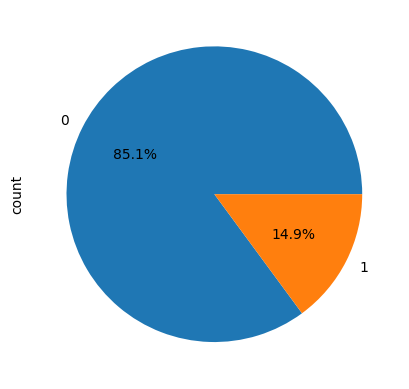

In [55]:
df['fbs'].value_counts().plot(kind='pie',autopct='%1.1f%%')

###restecg(`resting ECG`)
- Restecg is clean with 50% normal (0), 48.7% ST-T abnormality (1), and only 1.3% LV hypertrophy (2) — category 2 is too rare for reliable analysis.

In [56]:
df['restecg'].value_counts()

,count
restecg,
1,151
0,147
2,4


<Axes: ylabel='count'>

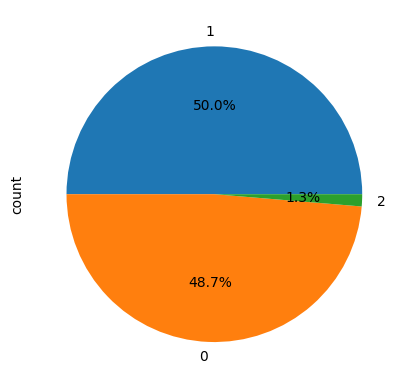

In [57]:
df['restecg'].value_counts().plot(kind='pie',autopct='%1.1f%%')

###exang column
- Exang is clean with 67.2% no angina and 32.8% exercise-induced angina — a clinically realistic distribution

In [58]:
df['exang'].value_counts()

,count
exang,
0,203
1,99


<Axes: ylabel='count'>

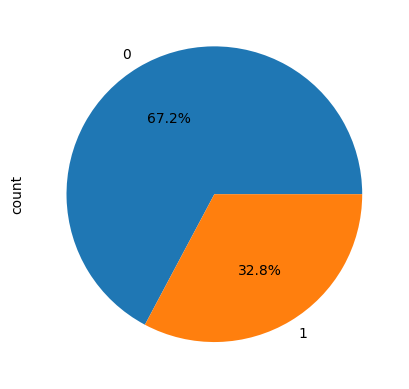

In [59]:
df['exang'].value_counts().plot(kind='pie',autopct='%1.1f%%')

###slope (`ST segment slope`)
- everything is fine in this column

In [60]:
df['slope'].value_counts()

,count
slope,
2,141
1,140
0,21


###ca (`number of major vessels colored by fluoroscopy`)
- everything is fine in this column

In [61]:
df['ca'].value_counts()

,count
ca,
0,175
1,65
2,38
3,20
4,4


###thal (`Thalasamia`)
- Thal is clean with 54.6% normal, 38.7% reversible defect, 6.0% fixed defect, and only 0.7% unknown — the unknown category needs handling. (`handled`)

In [62]:
df['thal'].value_counts()

,count
thal,
2,165
3,117
1,18
0,2


In [63]:
df['thal'] = df['thal'].replace({0: 3})

In [64]:
df['thal'].value_counts()

,count
thal,
2,165
3,119
1,18


###Target
- everything is normal in this column

In [65]:
df['target'].value_counts()

,count
target,
1,164
0,138


##Bivariate Analysis

In [66]:
from scipy import stats

# Define column types
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target = 'target'

###1. Numerical vs Target

####1.1 Statistical Tests (T-test/ANOVA)

**conclusion:**
- Bivariate analysis reveals surprising patterns: patients with heart disease are younger (52.6 vs 56.6), have lower blood pressure (129 vs 134), higher maximum heart rate (158 vs 139), and lower oldpeak (0.59 vs 1.59).
- Cholesterol shows no significant difference.

These findings suggest potential confounding, selection bias, or reversed target encoding in the dataset.

In [67]:
for col in numerical_cols:
    group_0 = df[df['target'] == 0][col]
    group_1 = df[df['target'] == 1][col]

    t_stat, p_value = stats.ttest_ind(group_0, group_1)

    print(f"\n{col}:")
    print(f"  Target=0 mean: {group_0.mean():.2f}")
    print(f"  Target=1 mean: {group_1.mean():.2f}")
    print(f"  Difference: {group_1.mean() - group_0.mean():.2f}")
    print(f"  T-test p-value: {p_value:.4f}")
    print(f"  Significant: {'✅ YES' if p_value < 0.05 else '❌ NO'}")


age:
  Target=0 mean: 56.60
  Target=1 mean: 52.59
  Difference: -4.02
  T-test p-value: 0.0001
  Significant: ✅ YES

trestbps:
  Target=0 mean: 134.40
  Target=1 mean: 129.25
  Difference: -5.15
  T-test p-value: 0.0109
  Significant: ✅ YES

chol:
  Target=0 mean: 251.09
  Target=1 mean: 242.64
  Difference: -8.45
  T-test p-value: 0.1580
  Significant: ❌ NO

thalach:
  Target=0 mean: 139.10
  Target=1 mean: 158.38
  Difference: 19.28
  T-test p-value: 0.0000
  Significant: ✅ YES

oldpeak:
  Target=0 mean: 1.59
  Target=1 mean: 0.59
  Difference: -1.00
  T-test p-value: 0.0000
  Significant: ✅ YES


####1.2 Boxplot

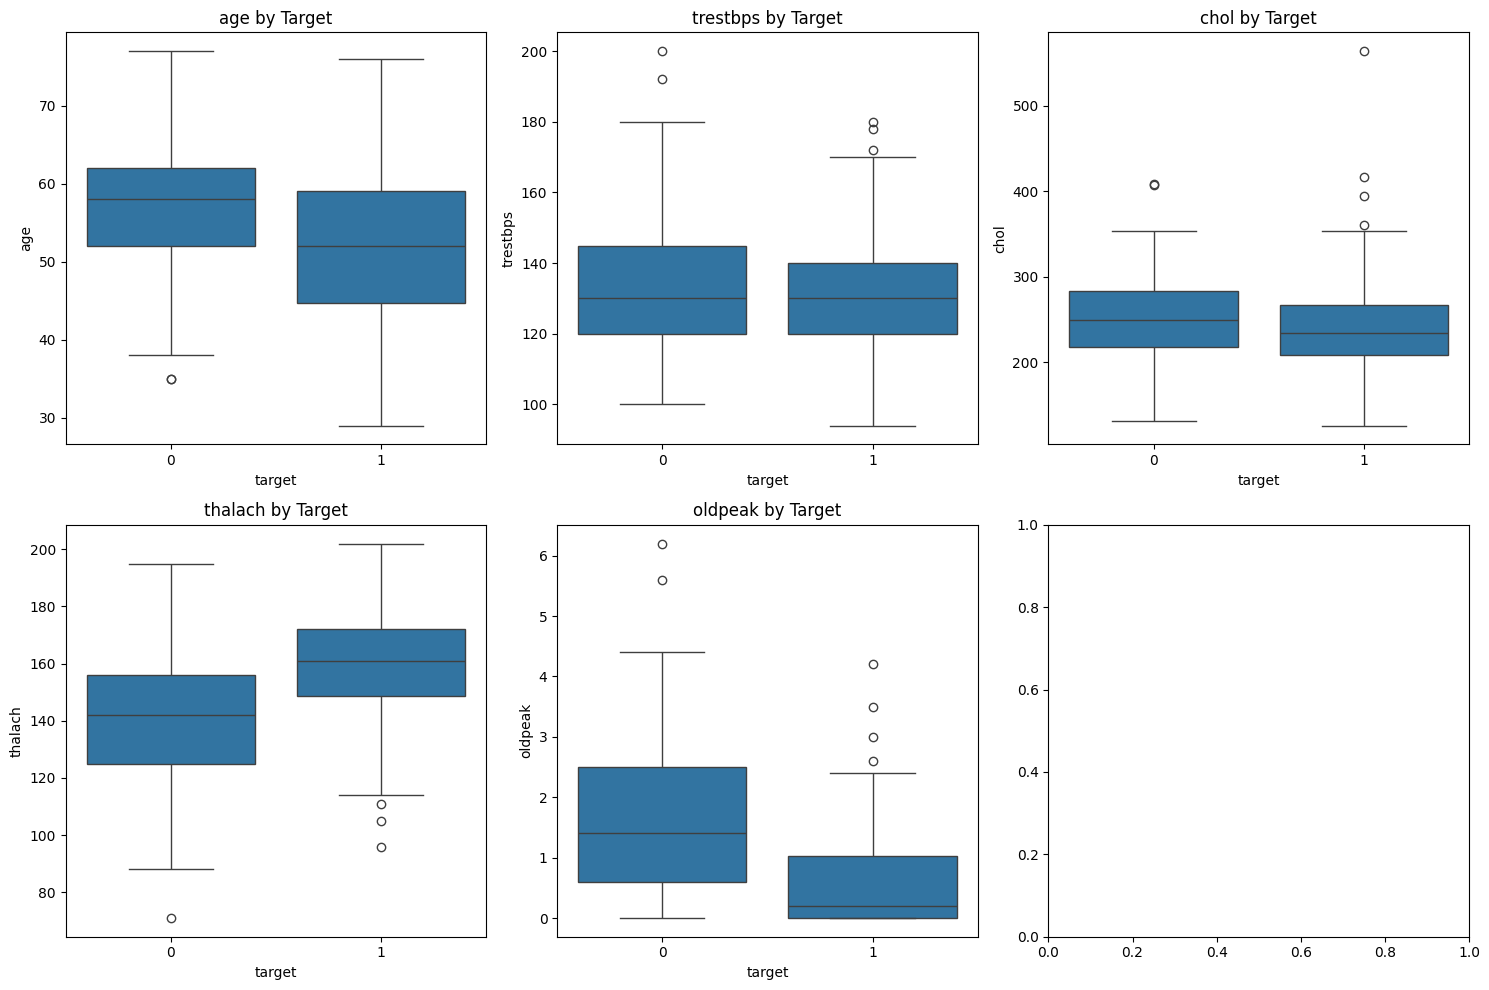

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Target')

plt.tight_layout()
plt.show()

###2. Categorical vs Target
**conclusion:**

The p-value of fbs (Fasting Blood Sugar)
is very high (0.76).


Therefore, Fasting blood sugar is not a distinguishing factor for heart disease in this dataset. We may drop this column

####2.1 Chi-square test with Crosstab Analysis


In [69]:
for col in categorical_cols:
    #crosstab
    crosstab = pd.crosstab(df[col], df['target'], normalize='index') * 100
    crosstab.columns = ['No Disease (%)', 'Disease (%)']
    crosstab['Count'] = df.groupby(col).size()

    # Chi-square test
    chi2, p_value, dof, expected = stats.chi2_contingency(
        pd.crosstab(df[col], df['target'])
    )

    print(f"\n{'-'*50}")
    print(f"{col}:")
    print(crosstab)
    print(f"Chi-square p-value: {p_value:.4f}")
    print(f"Significant: {'✅ YES' if p_value < 0.05 else '❌ NO'}")


--------------------------------------------------
sex:
     No Disease (%)  Disease (%)  Count
sex                                    
0         25.000000    75.000000     96
1         55.339806    44.660194    206
Chi-square p-value: 0.0000
Significant: ✅ YES

--------------------------------------------------
cp:
    No Disease (%)  Disease (%)  Count
cp                                    
0        72.727273    27.272727    143
1        18.000000    82.000000     50
2        20.930233    79.069767     86
3        30.434783    69.565217     23
Chi-square p-value: 0.0000
Significant: ✅ YES

--------------------------------------------------
fbs:
     No Disease (%)  Disease (%)  Count
fbs                                    
0         45.136187    54.863813    257
1         48.888889    51.111111     45
Chi-square p-value: 0.7611
Significant: ❌ NO

--------------------------------------------------
restecg:
         No Disease (%)  Disease (%)  Count
restecg                           

####2.2 Visualization with countplot

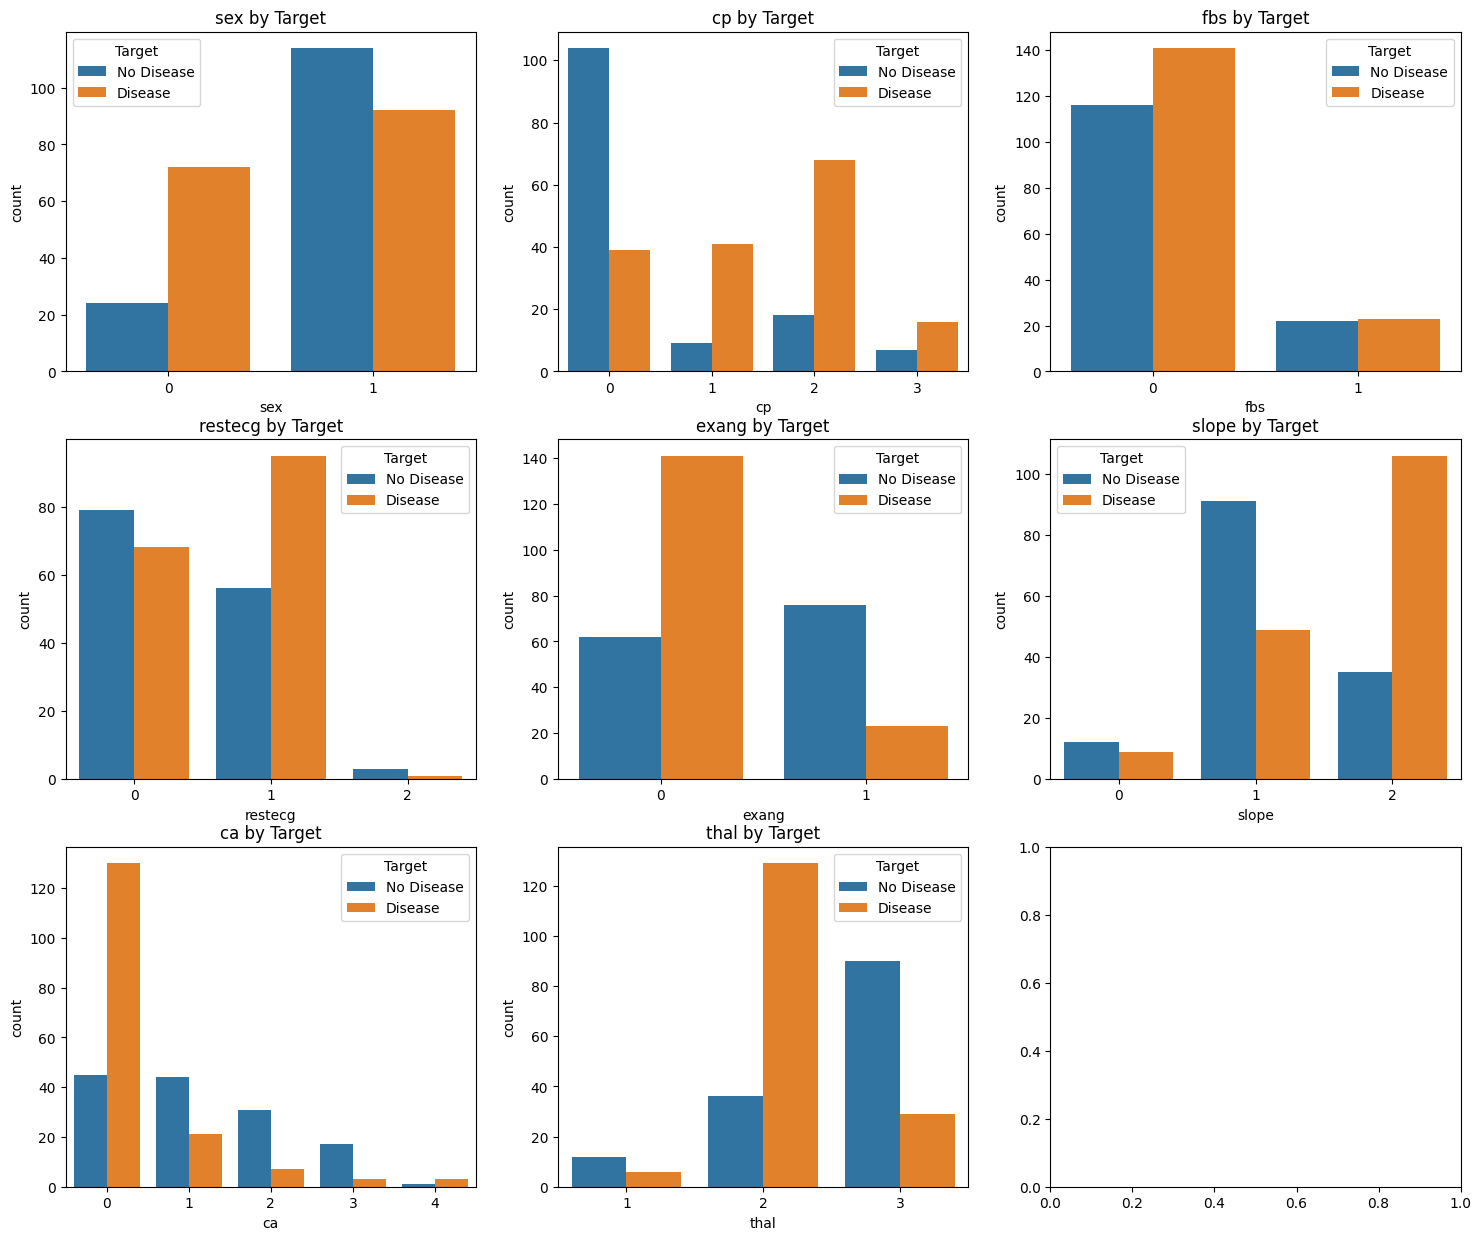

In [70]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='target', data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Target')
    axes[i].legend(title='Target', labels=['No Disease', 'Disease'])

####3. Numerical vs Numerical
**Conclusion:**
- **No Multicollinearity to fix:** Since none of the feature-to-feature correlations exceed ~0.40, we do not need to drop any numerical features to prevent redundancy. They all add unique variance to the dataset.

- **Modeling Expectation:** Based on this univariate and bivariate analysis, **`thalach` and `oldpeak`** are expected to be the most powerful numerical predictors. `chol` may end up being the least impactful.

In [71]:
correlation_matrix = df[numerical_cols].corr()

In [72]:
correlation_matrix

,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.283121,0.207216,-0.395235,0.206040
trestbps,0.283121,1.000000,0.125256,-0.048023,0.194600
chol,0.207216,0.125256,1.000000,-0.005308,0.050086
thalach,-0.395235,-0.048023,-0.005308,1.000000,-0.342201
oldpeak,0.206040,0.194600,0.050086,-0.342201,1.000000


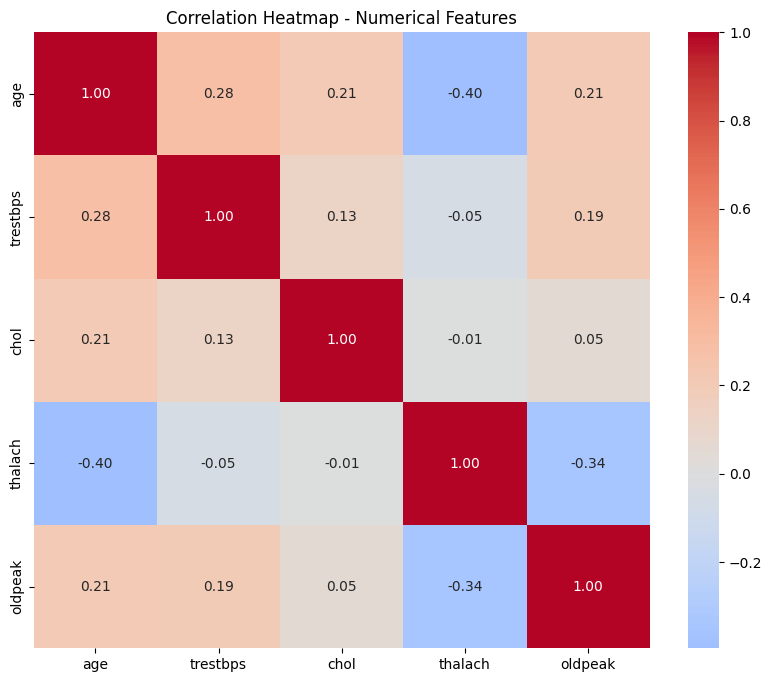

In [73]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True)
plt.title('Correlation Heatmap - Numerical Features')
plt.show()

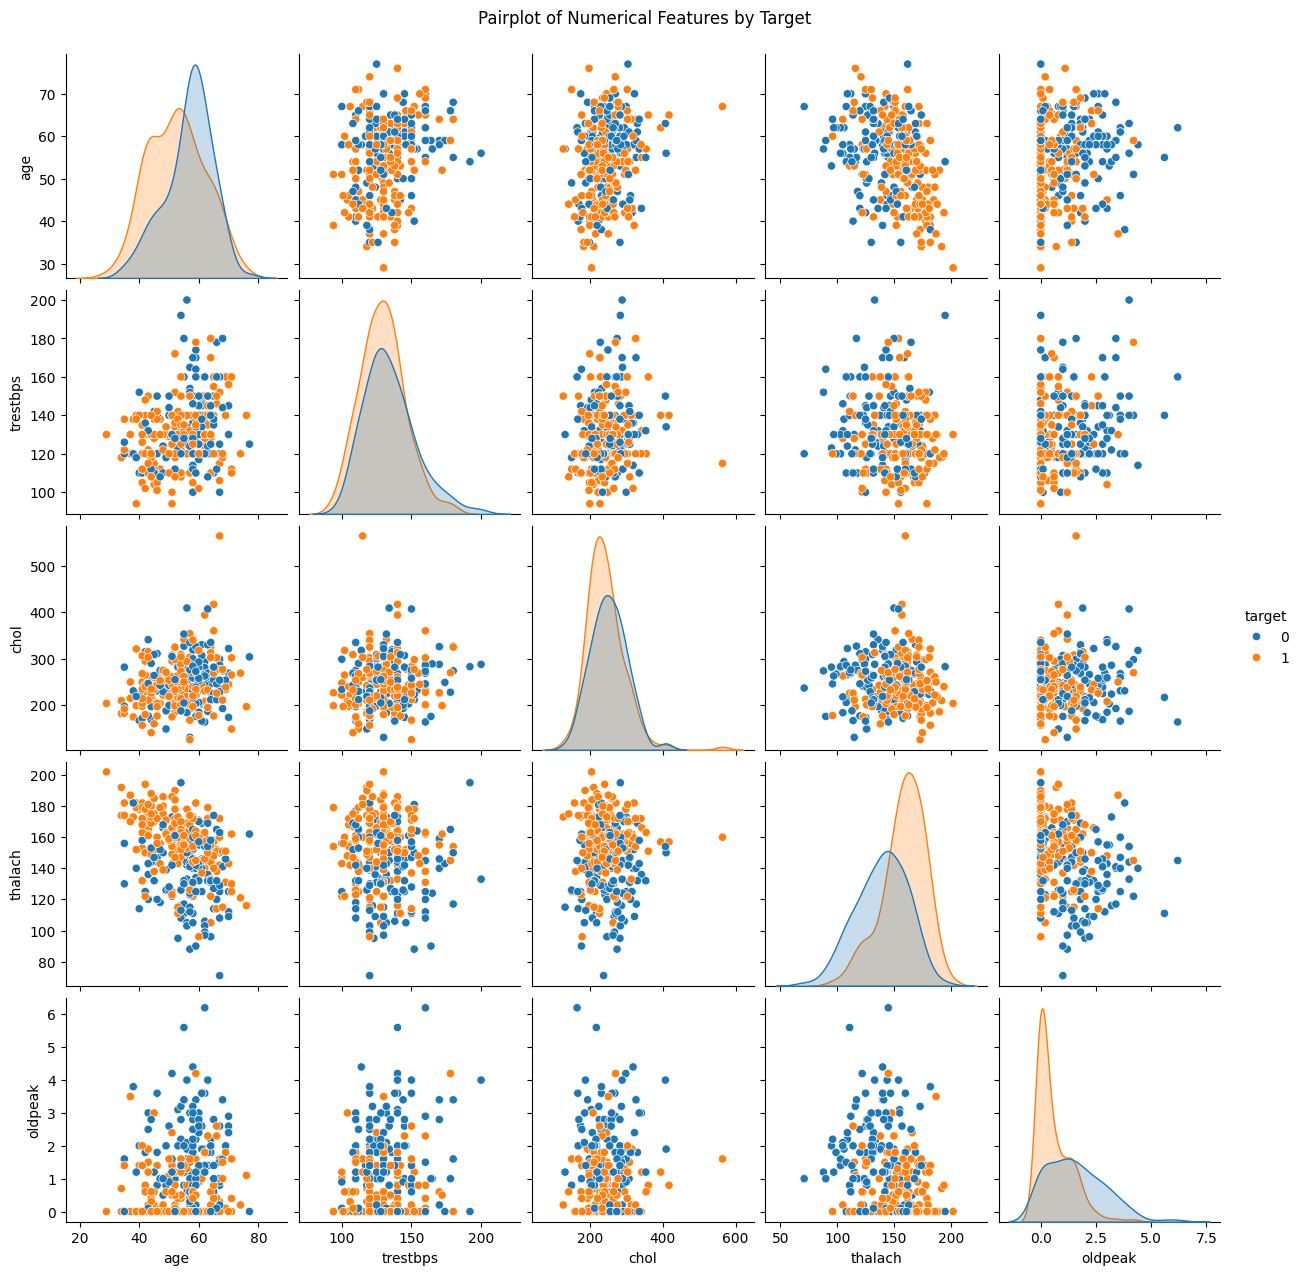

In [74]:
sns.pairplot(df, vars=numerical_cols, hue='target', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Target', y=1.02)
plt.show()

####4. Categorical vs Categorical

**Conclusion:**

- Chest pain type (cp) shows strong associations with thalassemia (thal) and exercise angina (exang) with ST slope (slope), and vessel count (ca) with thalassemia (thal) — these pairs should be considered for interaction terms in modeling. Sex and resting ECG show no significant associations with other categorical features.

In [75]:
cat_pairs = [('sex', 'cp'), ('cp', 'thal'), ('exang', 'slope'),
             ('ca', 'thal'), ('restecg', 'exang')]

for col1, col2 in cat_pairs:
    crosstab = pd.crosstab(df[col1], df[col2], normalize='index') * 100
    print(f"\n{col1} vs {col2}:")
    print(crosstab.round(1))

    # Chi-square test
    chi2, p_value, dof, expected = stats.chi2_contingency(
        pd.crosstab(df[col1], df[col2])
    )
    print(f"Chi-square p-value: {p_value:.4f}")
    print(f"Significant: {'✅ YES' if p_value < 0.05 else '❌ NO'}")


sex vs cp:
cp      0     1     2    3
sex                       
0    40.6  18.8  36.5  4.2
1    50.5  15.5  24.8  9.2
Chi-square p-value: 0.0688
Significant: ❌ NO

cp vs thal:
thal    1     2     3
cp                   
0     8.4  36.4  55.2
1     4.0  78.0  18.0
2     2.3  70.9  26.7
3     8.7  56.5  34.8
Chi-square p-value: 0.0000
Significant: ✅ YES

exang vs slope:
slope    0     1     2
exang                 
0      5.9  37.4  56.7
1      9.1  64.6  26.3
Chi-square p-value: 0.0000
Significant: ✅ YES

ca vs thal:
thal     1     2     3
ca                    
0      4.6  65.1  30.3
1      6.2  44.6  49.2
2     10.5  36.8  52.6
3     10.0  30.0  60.0
4      0.0  50.0  50.0
Chi-square p-value: 0.0069
Significant: ✅ YES

restecg vs exang:
exang       0     1
restecg            
0        63.3  36.7
1        71.5  28.5
2        50.0  50.0
Chi-square p-value: 0.2404
Significant: ❌ NO


###5. Categorical vs Numerical

**Conclusion:**

- Thalach and oldpeak are the most strongly associated with categorical features (all p=0.0000), while cholesterol and sex show the weakest associations

In [76]:
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        # Group statistics
        grouped = df.groupby(cat_col)[num_col].agg(['mean', 'std', 'count'])
        print(f"\n{num_col} by {cat_col}:")
        print(grouped)

        # ANOVA (if more than 2 categories)
        groups = [df[df[cat_col] == val][num_col].values for val in df[cat_col].unique()]
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"ANOVA p-value: {p_value:.4f}")
        print(f"Significant: {'✅ YES' if p_value < 0.05 else '❌ NO'}")


age by sex:
          mean       std  count
sex                            
0    55.677083  9.409396     96
1    53.834951  8.836838    206
ANOVA p-value: 0.0995
Significant: ❌ NO

age by cp:
         mean        std  count
cp                             
0   55.692308   8.312752    143
1   51.360000   9.512098     50
2   53.697674   9.323051     86
3   55.869565  10.033147     23
ANOVA p-value: 0.0207
Significant: ✅ YES

age by fbs:
          mean       std  count
fbs                            
0    53.968872  9.290400    257
1    57.000000  7.061419     45
ANOVA p-value: 0.0380
Significant: ✅ YES

age by restecg:
              mean        std  count
restecg                             
0        55.687075   8.675902    147
1        53.013245   9.178952    151
2        61.000000  10.099505      4
ANOVA p-value: 0.0128
Significant: ✅ YES

age by exang:
            mean       std  count
exang                            
0      53.832512  9.327460    203
1      55.626263  8.362435     9

#Machine Learning Pipeline

In [244]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, Normalizer,FunctionTransformer,PowerTransformer, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [326]:
X = df.drop(['target','fbs'], axis=1)
y = df['target']

In [327]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

###Preprocessor


In [328]:
normal_cols = ['age', 'trestbps']
skewed_cols = ['chol', 'thalach', 'oldpeak']

preprocessor = ColumnTransformer([
    ('normal', MinMaxScaler(), normal_cols),
    ('skewed',
     Pipeline([
         ('power', PowerTransformer()),
         ('scaler', MinMaxScaler())
     ]),
     skewed_cols)
], remainder='passthrough')

###Preprocessor for models that don't need scaling

In [329]:
tree_preprocessor = 'passthrough'

###Trying different model

###1. Logistic Regression + GridSearchCV

In [330]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [331]:
lr_params = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__penalty': ['l1', 'l2']
}

In [332]:
lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('normal',
                                                                         MinMaxScaler(),
                                                                         ['age',
                                                                          'trestbps']),
                                                                        ('skewed',
                                                                         Pipeline(steps=[('power',
                                                                                          PowerTransformer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['chol',
                                                                          'thalach',
                                                                          'oldpeak'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [333]:
print("Best Parameters:", lr_grid.best_params_)
print("Best CV Score:", lr_grid.best_score_)

Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV Score: 0.821513605442177


In [334]:
lr_best = lr_grid.best_estimator_

In [335]:
y_pred = lr_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.819672131147541
              precision    recall  f1-score   support

           0       0.96      0.69      0.80        32
           1       0.74      0.97      0.84        29

    accuracy                           0.82        61
   macro avg       0.85      0.83      0.82        61
weighted avg       0.85      0.82      0.82        61



###2. DecisionTree + GridSearchCV

In [336]:
dt_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

gridsearch cv

In [337]:
dt_params = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_model,
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [338]:
dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)

Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best CV Score: 0.7550170068027212


In [340]:
dt_best = dt_grid.best_estimator_

y_pred = dt_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7540983606557377
              precision    recall  f1-score   support

           0       0.76      0.78      0.77        32
           1       0.75      0.72      0.74        29

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



###2. Random Forest + GridSearchCV

In [341]:
rf_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

Best Parameters: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV Score: 0.8383503401360544


In [342]:
rf_best = rf_grid.best_estimator_

y_pred = rf_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        32
           1       0.79      0.93      0.86        29

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



###3.KNN + GridSearchCV

In [343]:
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

knn_params = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}

knn_grid = GridSearchCV(
    knn_model,
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)

Best Parameters: {'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best CV Score: 0.8421768707482993


In [344]:
knn_best = knn_grid.best_estimator_

y_pred = knn_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        32
           1       0.79      0.93      0.86        29

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



###5. SVM + GridSearchCV

In [345]:
svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

svm_params = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    svm_model,
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)

Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best CV Score: 0.821513605442177


In [346]:
svm_best = svm_grid.best_estimator_

y_pred = svm_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       1.00      0.75      0.86        32
           1       0.78      1.00      0.88        29

    accuracy                           0.87        61
   macro avg       0.89      0.88      0.87        61
weighted avg       0.90      0.87      0.87        61



###6. XGBoost + GridSearchCV

In [347]:
xgb_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [348]:
xgb_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)

Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best CV Score: 0.8215986394557822


In [349]:
xgb_best = xgb_grid.best_estimator_

y_pred = xgb_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [319]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [350]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

In [351]:
models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

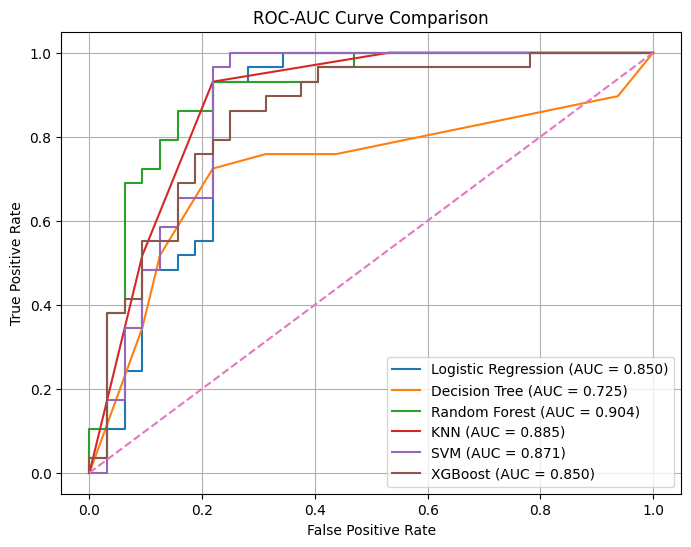

In [352]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    # Models with probability estimates
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]

    # SVM can use decision_function
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")

plt.legend()
plt.grid()

plt.show()

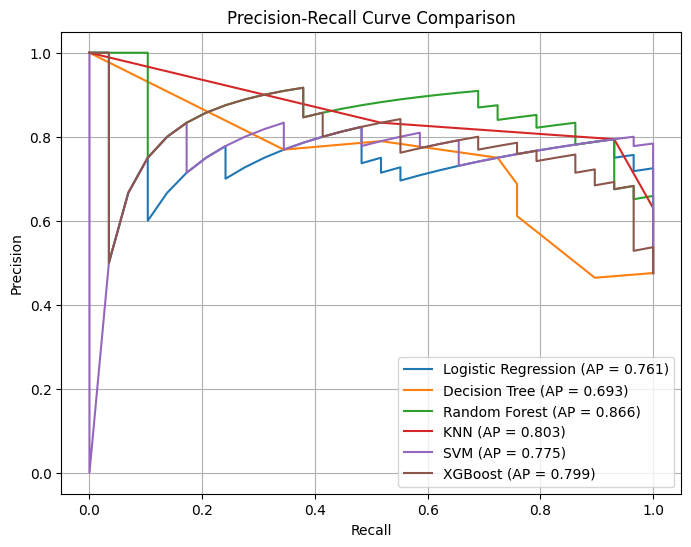

In [354]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        y_score
    )

    ap_score = average_precision_score(y_test, y_score)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap_score:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()
plt.grid()

plt.show()

## **Final Model Selection**

After training and tuning six different machine learning models, I compared their performance using cross-validation, test-set metrics, ROC-AUC, and Precision-Recall analysis.

Based on the overall results, **Random Forest was selected as the final model**. It achieved the highest ROC-AUC score (**0.904**) and the highest Average Precision score (**0.866**) among all six models. This suggests that Random Forest was better at distinguishing between the two classes and maintaining a strong balance between precision and recall on the evaluated data.

Interestingly, **K-Nearest Neighbors (KNN)** achieved a higher test accuracy in the earlier model comparison. However, its ROC-AUC (**0.885**) and Average Precision (**0.803**) were lower than those of Random Forest. This showed me that accuracy alone was not enough to decide which model performed best.

The Precision-Recall analysis also supported the choice of Random Forest. At a selected threshold where the model achieved approximately **0.90 recall**, its precision was approximately **0.81** on the evaluated data. This demonstrates a useful trade-off between identifying positive cases and limiting false positives.

Considering all of these results together, **Random Forest was chosen as the final model for this project**.




### **Important Limitations**

One important limitation of this project is the relatively small dataset. After removing duplicate observations, only **302 unique records** remained. Because of this, the results should be viewed as an evaluation of the model on this particular dataset rather than evidence of real-world clinical performance.

A larger, independent dataset would be needed to properly evaluate how well the model generalizes to new populations. External validation and further testing would also be necessary before considering any machine learning model for actual medical use.

This project was developed for **educational and machine learning practice purposes** and should not be used as a medical diagnostic tool.